In [ ]:
Perform the following operations using Python on census bureau databset(Adult data sets)
m. Data cleaning(Remove NA, ?, Negative values etc.)
n. Error correcting(Outlier detection and removal)
o. Data transformation
p. Build Data model using regression and Naïve Bayes methods for prediction of
income category (>=50k or <=50k) and compare accuracy Prediction.

In [5]:
import pandas as pd
import numpy as np

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import GaussianNB
from sklearn.metrics import accuracy_score


# =========================================================
# LOAD DATASET
# =========================================================

columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

df = pd.read_csv(
    "adult.csv",
    header=None,
    names=columns,
    skipinitialspace=True
)

print("First 5 Rows:")
print(df.head())

# =========================================================
# m. DATA CLEANING
# =========================================================

# Replace ? with NaN
df.replace('?', np.nan, inplace=True)

# Remove missing values
df.dropna(inplace=True)

# Remove negative values
numeric_cols = [
    'age',
    'fnlwgt',
    'education_num',
    'capital_gain',
    'capital_loss',
    'hours_per_week'
]

for col in numeric_cols:
    df = df[df[col] >= 0]

print("\nDataset Shape After Cleaning:")
print(df.shape)

# =========================================================
# n. OUTLIER DETECTION & REMOVAL
# =========================================================

for col in numeric_cols:

    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)

    IQR = Q3 - Q1

    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR

    df = df[(df[col] >= lower) & (df[col] <= upper)]

print("\nDataset Shape After Outlier Removal:")
print(df.shape)

# =========================================================
# o. DATA TRANSFORMATION
# Convert categorical columns to numeric
# =========================================================

label_encoder = LabelEncoder()

categorical_cols = [
    'workclass',
    'education',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'native_country',
    'income'
]

for col in categorical_cols:
    df[col] = label_encoder.fit_transform(df[col])

print("\nEncoded Dataset:")
print(df.head())

# =========================================================
# p. BUILD DATA MODELS
# =========================================================

# Features and Target
X = df.drop('income', axis=1)

y = df['income']

# Split Dataset
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

# =========================================================
# FEATURE SCALING
# =========================================================

scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# =========================================================
# LOGISTIC REGRESSION
# =========================================================

lr = LogisticRegression(max_iter=2000)

lr.fit(X_train, y_train)

lr_pred = lr.predict(X_test)

lr_accuracy = accuracy_score(y_test, lr_pred)

print("\n===== Logistic Regression =====")
print("Accuracy:", lr_accuracy)

# =========================================================
# NAIVE BAYES
# =========================================================

nb = GaussianNB()

nb.fit(X_train, y_train)

nb_pred = nb.predict(X_test)

nb_accuracy = accuracy_score(y_test, nb_pred)

print("\n===== Naive Bayes =====")
print("Accuracy:", nb_accuracy)

# =========================================================
# COMPARISON
# =========================================================

print("\n===== Accuracy Comparison =====")

print("Logistic Regression Accuracy :", lr_accuracy)

print("Naive Bayes Accuracy         :", nb_accuracy)

if lr_accuracy > nb_accuracy:
    print("\nLogistic Regression Performs Better")
else:
    print("\nNaive Bayes Performs Better")

First 5 Rows:
   age         workclass  fnlwgt  education  education_num  \
0   39         State-gov   77516  Bachelors             13   
1   50  Self-emp-not-inc   83311  Bachelors             13   
2   38           Private  215646    HS-grad              9   
3   53           Private  234721       11th              7   
4   28           Private  338409  Bachelors             13   

       marital_status         occupation   relationship   race     sex  \
0       Never-married       Adm-clerical  Not-in-family  White    Male   
1  Married-civ-spouse    Exec-managerial        Husband  White    Male   
2            Divorced  Handlers-cleaners  Not-in-family  White    Male   
3  Married-civ-spouse  Handlers-cleaners        Husband  Black    Male   
4  Married-civ-spouse     Prof-specialty           Wife  Black  Female   

   capital_gain  capital_loss  hours_per_week native_country income  
0          2174             0              40  United-States  <=50K  
1             0             

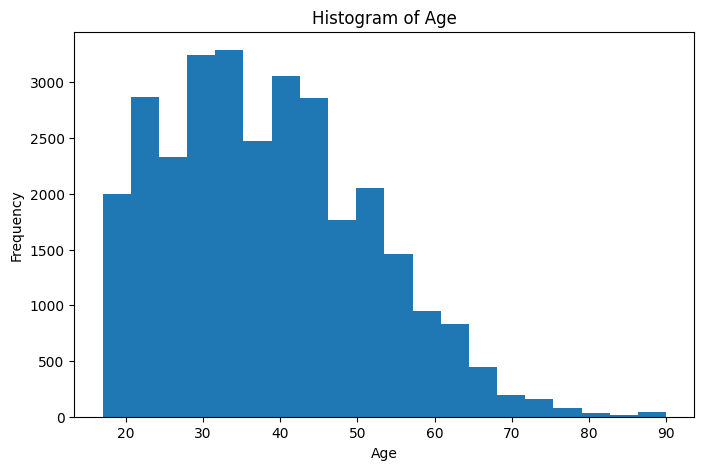

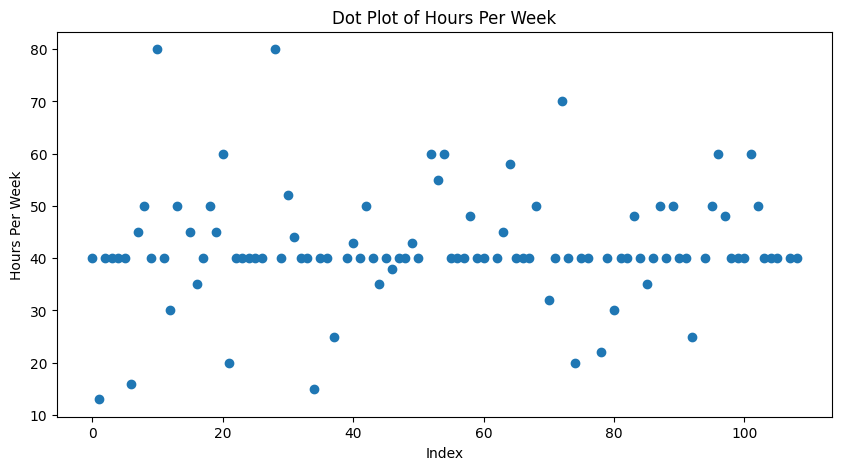

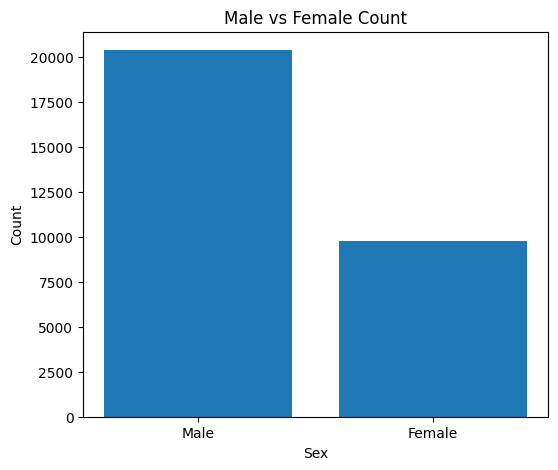

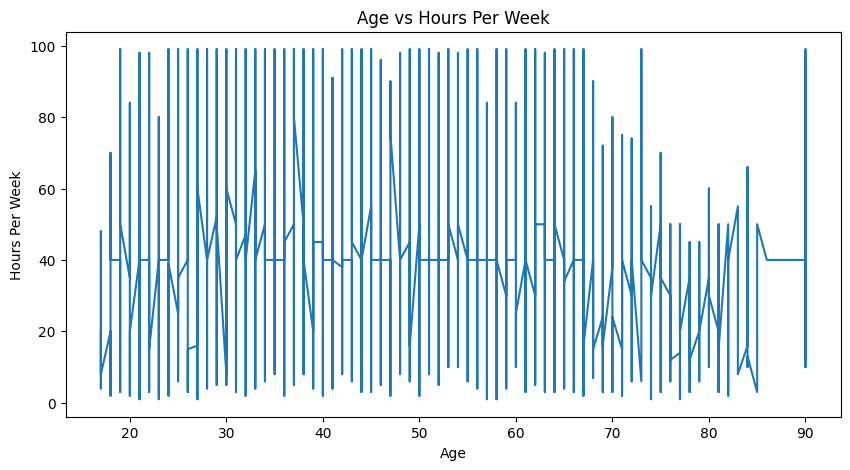

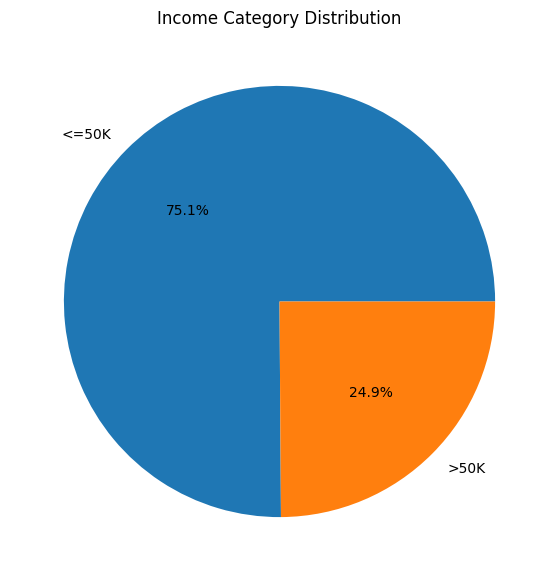

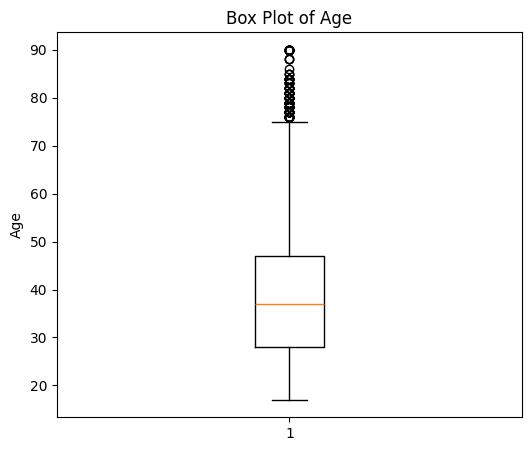

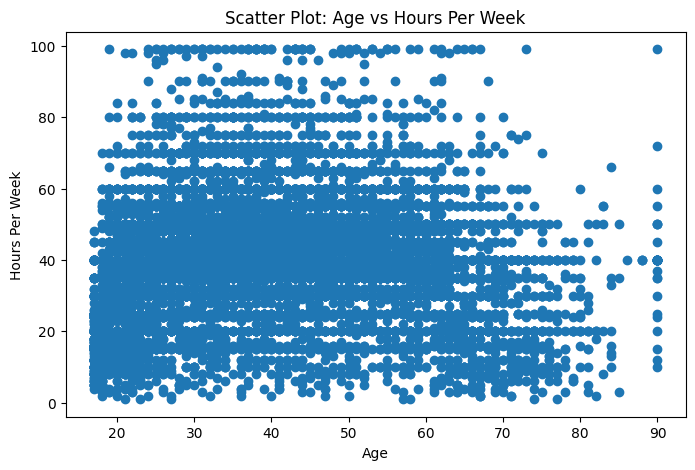

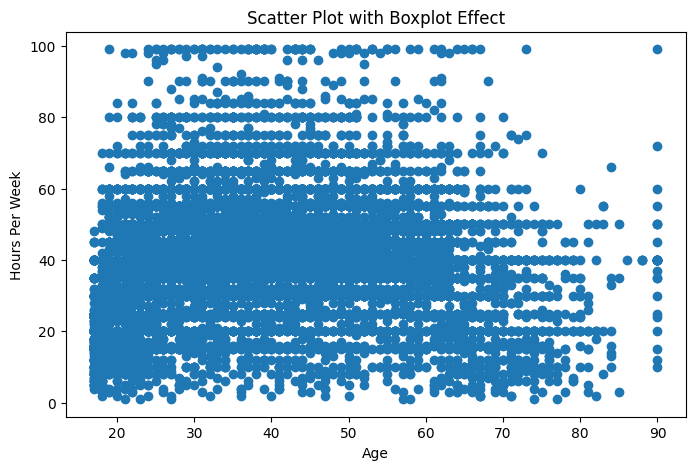

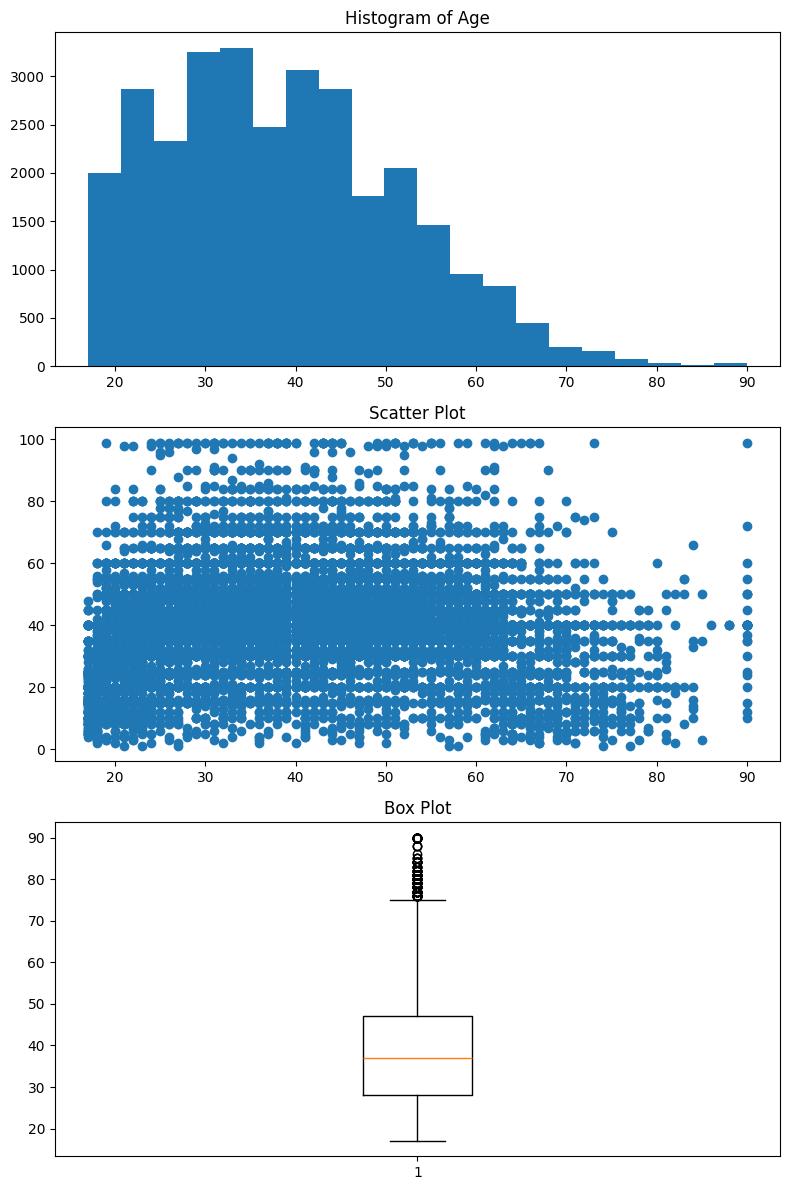

In [6]:
# =========================================================
# Adult Census Dataset Visualization
# =========================================================

import pandas as pd
import matplotlib.pyplot as plt

# =========================================================
# LOAD DATASET
# =========================================================

columns = [
    'age',
    'workclass',
    'fnlwgt',
    'education',
    'education_num',
    'marital_status',
    'occupation',
    'relationship',
    'race',
    'sex',
    'capital_gain',
    'capital_loss',
    'hours_per_week',
    'native_country',
    'income'
]

df = pd.read_csv(
    "adult.csv",
    header=None,
    names=columns,
    skipinitialspace=True
)

# =========================================================
# DATA CLEANING
# =========================================================

df.replace('?', pd.NA, inplace=True)
df.dropna(inplace=True)

# =========================================================
# f. HISTOGRAM
# Objective:
# Show distribution of age
# =========================================================

plt.figure(figsize=(8,5))

plt.hist(df['age'], bins=20)

plt.title("Histogram of Age")

plt.xlabel("Age")

plt.ylabel("Frequency")

plt.show()

# =========================================================
# g. DOT PLOT
# Objective:
# Show individual hours worked per week
# =========================================================

plt.figure(figsize=(10,5))

plt.plot(df.index[:100],
         df['hours_per_week'][:100],
         'o')

plt.title("Dot Plot of Hours Per Week")

plt.xlabel("Index")

plt.ylabel("Hours Per Week")

plt.show()

# =========================================================
# h. BAR PLOT
# Objective:
# Compare count of males and females
# =========================================================

sex_count = df['sex'].value_counts()

plt.figure(figsize=(6,5))

plt.bar(sex_count.index,
        sex_count.values)

plt.title("Male vs Female Count")

plt.xlabel("Sex")

plt.ylabel("Count")

plt.show()

# =========================================================
# i. LINE CHART
# Objective:
# Show relationship between age and hours worked
# =========================================================

sorted_df = df.sort_values('age')

plt.figure(figsize=(10,5))

plt.plot(sorted_df['age'],
         sorted_df['hours_per_week'])

plt.title("Age vs Hours Per Week")

plt.xlabel("Age")

plt.ylabel("Hours Per Week")

plt.show()

# =========================================================
# b. PIE CHART
# Objective:
# Show income category proportion
# =========================================================

income_count = df['income'].value_counts()

plt.figure(figsize=(7,7))

plt.pie(
    income_count.values,
    labels=income_count.index,
    autopct='%1.1f%%'
)

plt.title("Income Category Distribution")

plt.show()

# =========================================================
# c. BOX PLOT
# Objective:
# Detect outliers in age
# =========================================================

plt.figure(figsize=(6,5))

plt.boxplot(df['age'])

plt.title("Box Plot of Age")

plt.ylabel("Age")

plt.show()

# =========================================================
# d. SCATTER PLOT
# Objective:
# Relationship between age and hours per week
# =========================================================

plt.figure(figsize=(8,5))

plt.scatter(
    df['age'],
    df['hours_per_week']
)

plt.title("Scatter Plot: Age vs Hours Per Week")

plt.xlabel("Age")

plt.ylabel("Hours Per Week")

plt.show()

# =========================================================
# e. ADD BOXPLOTS TO SCATTERPLOT
# Objective:
# Visualize distribution + relationship together
# =========================================================

fig, ax = plt.subplots(figsize=(8,5))

ax.scatter(
    df['age'],
    df['hours_per_week']
)

ax.set_title("Scatter Plot with Boxplot Effect")

ax.set_xlabel("Age")

ax.set_ylabel("Hours Per Week")

plt.show()

# =========================================================
# j. HISTOGRAM + SCATTER PLOT + BOXPLOT
# Objective:
# Combined visualization of age distribution
# =========================================================

fig, axs = plt.subplots(3, 1, figsize=(8,12))

# Histogram
axs[0].hist(df['age'], bins=20)
axs[0].set_title("Histogram of Age")

# Scatter Plot
axs[1].scatter(
    df['age'],
    df['hours_per_week']
)
axs[1].set_title("Scatter Plot")

# Box Plot
axs[2].boxplot(df['age'])
axs[2].set_title("Box Plot")

plt.tight_layout()

plt.show()